XGBoost

XGB - PCA

In [2]:
import numpy as np

# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# PCA Features
X_train_pca = np.load("X_train_pca.npy")
X_val_pca   = np.load("X_val_pca.npy")
X_test_pca  = np.load("X_test_pca.npy")

Baseline

In [3]:
xgb_baseline_pca = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_baseline_pca.fit(X_train_pca, y_train)

print("Baseline XGB + PCA Validation:", xgb_baseline_pca.score(X_val_pca, y_val))
print("Baseline XGB + PCA Test:", xgb_baseline_pca.score(X_test_pca, y_test))

Baseline XGB + PCA Validation: 0.9246575342465754
Baseline XGB + PCA Test: 0.8175675675675675


Parameter Tuning

In [4]:
param_grid_xgb = {
    "n_estimators": [300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [5]:
from sklearn.model_selection import GridSearchCV

grid_xgb_pca = GridSearchCV(
    XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),
    param_grid_xgb,
    scoring="accuracy",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_xgb_pca.fit(X_train_pca, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05], 'max_depth': [4, 6, ...], 'n_estimators': [300, 500], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [6]:
print("Best Params:", grid_xgb_pca.best_params_)
print("Best CV Score:", grid_xgb_pca.best_score_)

best_xgb_pca = grid_xgb_pca.best_estimator_

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}
Best CV Score: 0.8423965141612202


In [7]:
val_acc = best_xgb_pca.score(X_val_pca, y_val)
test_acc = best_xgb_pca.score(X_test_pca, y_test)

print("Tuned XGB + PCA Validation:", val_acc)
print("Tuned XGB + PCA Test:", test_acc)

Tuned XGB + PCA Validation: 0.9246575342465754
Tuned XGB + PCA Test: 0.8108108108108109


In [8]:
xgb_improved_pca = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_improved_pca.fit(X_train_pca, y_train)

print("Improved XGB + PCA Validation:", xgb_improved_pca.score(X_val_pca, y_val))
print("Improved XGB + PCA Test:", xgb_improved_pca.score(X_test_pca, y_test))

Improved XGB + PCA Validation: 0.9246575342465754
Improved XGB + PCA Test: 0.8243243243243243


c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-package

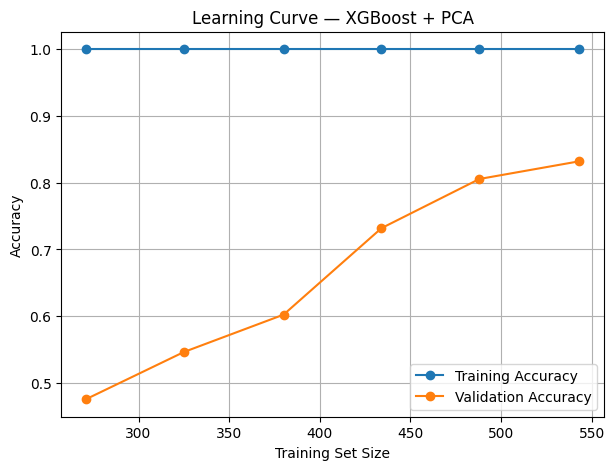

In [31]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    xgb_improved_pca,
    X_train_pca,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — XGBoost + PCA")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

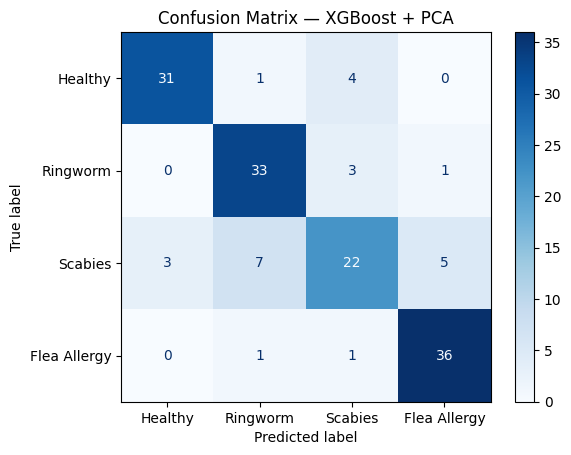

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = xgb_improved_pca.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Ringworm","Scabies","Flea Allergy"])

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost + PCA")
plt.show()

In [33]:
from sklearn.metrics import classification_report

y_test_pred = xgb_improved_pca.predict(X_test_pca)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89        36
           1       0.79      0.89      0.84        37
           2       0.73      0.59      0.66        37
           3       0.86      0.95      0.90        38

    accuracy                           0.82       148
   macro avg       0.82      0.82      0.82       148
weighted avg       0.82      0.82      0.82       148



XGB - MI

In [47]:
# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# MI Features
X_train_mi = np.load("X_train_mi.npy")
X_val_mi   = np.load("X_val_mi.npy")
X_test_mi  = np.load("X_test_mi.npy")

Baseline

In [10]:
from xgboost import XGBClassifier

xgb_baseline_mi = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_baseline_mi.fit(X_train_mi, y_train)

print("Baseline XGB + MI Validation:", xgb_baseline_mi.score(X_val_mi, y_val))
print("Baseline XGB + MI Test:", xgb_baseline_mi.score(X_test_mi, y_test))

Baseline XGB + MI Validation: 0.9041095890410958
Baseline XGB + MI Test: 0.831081081081081


Parameter Tuning

In [ ]:
xgb_improved_mi = XGBClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
)

xgb_improved_mi.fit(X_train_mi, y_train)


print("Improved XGB + MI Validation:", xgb_improved_mi.score(X_val_mi, y_val))
print("Improved XGB + MI Test:", xgb_improved_mi.score(X_test_mi, y_test))

Improved XGB + MI Validation: 0.9041095890410958
Improved XGB + MI Test: 0.8445945945945946


c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-package

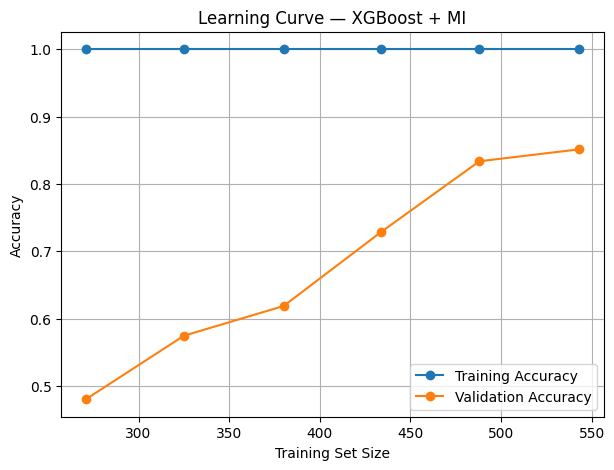

In [57]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    xgb_improved_mi,
    X_train_mi,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — XGBoost + MI")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

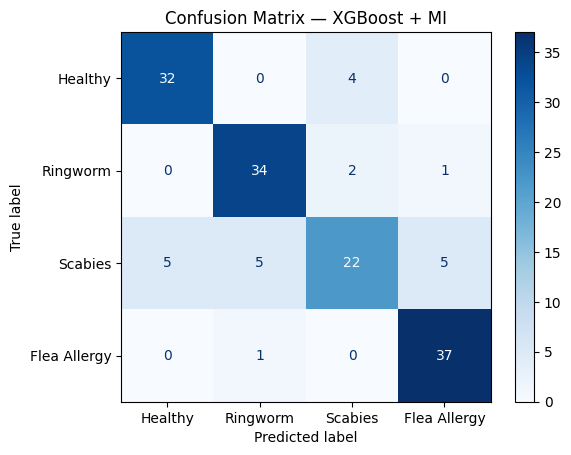

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = xgb_improved_mi.predict(X_test_mi)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy","Ringworm","Scabies","Flea Allergy"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost + MI")
plt.show()

In [59]:
from sklearn.metrics import classification_report

y_test_pred = xgb_improved_mi.predict(X_test_mi)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88        36
           1       0.85      0.92      0.88        37
           2       0.79      0.59      0.68        37
           3       0.86      0.97      0.91        38

    accuracy                           0.84       148
   macro avg       0.84      0.84      0.84       148
weighted avg       0.84      0.84      0.84       148



XGB + Boruta

In [4]:
# Labels
y_train = np.load("y_train_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")

# MI Features
X_train_boruta = np.load("X_train_boruta.npy")
X_val_boruta   = np.load("X_val_boruta.npy")
X_test_boruta  = np.load("X_test_boruta.npy")

Baseline

In [14]:
from xgboost import XGBClassifier

xgb_baseline_boruta = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_baseline_boruta.fit(X_train_boruta, y_train)

print("Baseline XGB + Boruta Validation:", xgb_baseline_boruta.score(X_val_boruta, y_val))
print("Baseline XGB + Boruta Test:", xgb_baseline_boruta.score(X_test_boruta, y_test))

Baseline XGB + Boruta Validation: 0.9041095890410958
Baseline XGB + Boruta Test: 0.8243243243243243


Parameter Tuning

In [70]:
xgb_improved_boruta = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_improved_boruta.fit(X_train_boruta, y_train)

print("Improved XGB + Boruta Validation:", xgb_improved_boruta.score(X_val_boruta, y_val))
print("Improved XGB + Boruta Test:", xgb_improved_boruta.score(X_test_boruta, y_test))

Improved XGB + Boruta Validation: 0.9041095890410958
Improved XGB + Boruta Test: 0.8378378378378378


In [16]:
xgb_regularized_boruta = XGBClassifier(
    n_estimators=700,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_regularized_boruta.fit(X_train_boruta, y_train)

print("Regularized XGB + Boruta Validation:", xgb_regularized_boruta.score(X_val_boruta, y_val))
print("Regularized XGB + Boruta Test:", xgb_regularized_boruta.score(X_test_boruta, y_test))

Regularized XGB + Boruta Validation: 0.8972602739726028
Regularized XGB + Boruta Test: 0.8378378378378378


c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\chanu\OneDrive - Informatics Institute of Technology\Desktop\IRP\Cat Skin DIsease Classification\.venv\lib\site-package

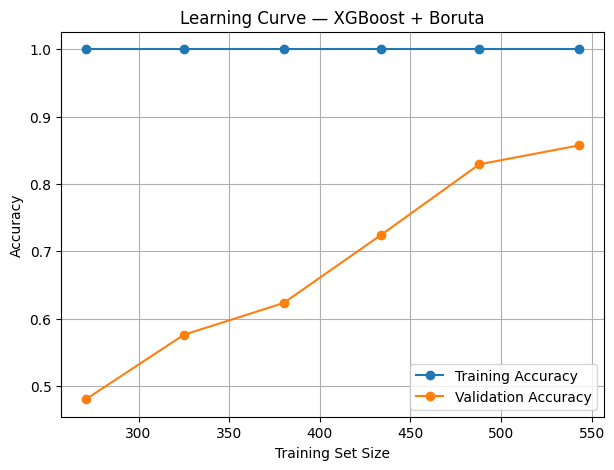

In [71]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    xgb_improved_boruta,
    X_train_boruta,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — XGBoost + Boruta")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x500 with 0 Axes>

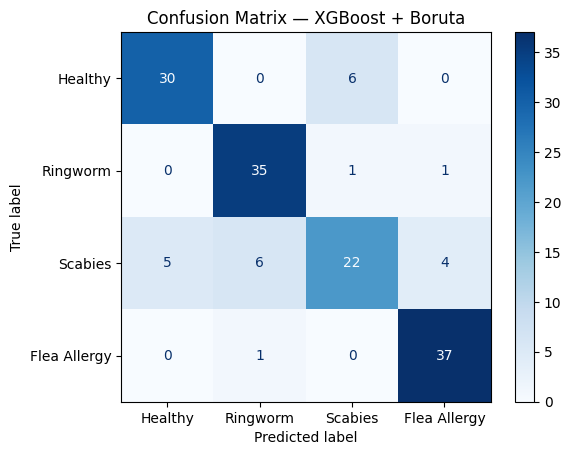

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = xgb_improved_boruta.predict(X_test_boruta)

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy","Ringworm","Scabies","Flea Allergy"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost + Boruta")
plt.show()

In [73]:
from sklearn.metrics import classification_report

y_test_pred = xgb_improved_boruta.predict(X_test_boruta)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        36
           1       0.83      0.95      0.89        37
           2       0.76      0.59      0.67        37
           3       0.88      0.97      0.93        38

    accuracy                           0.84       148
   macro avg       0.83      0.84      0.83       148
weighted avg       0.83      0.84      0.83       148

